In [ ]:
# Import the FEMSystem Class from directory above
import sys
from VisualizeVF import VisualizeVF
sys.path.append('..')
from FEMSystem import FEMSystem
from minimal_coupling_four_terms

import jax.numpy as jnp
import pickle
import matplotlib.pyplot as plt
import numpy as np


# Solve for A(x,t) given $\rho$

In [9]:
# First load in 2D mesh and 2D modes (statics solution)
pickled_obj = {}

with open('./../2D/allplots/square10sep20num100/results.pkl', 'rb') as f:
    pickled_obj= pickle.load(f)

femsystem:FEMSystem = pickled_obj["femsystem"]
femsystem.saveFigsDir = None # Turn OFF saving plots
u_even,u_odd = pickled_obj["u_even"],pickled_obj["u_odd"]
u_left,u_right = 1/jnp.sqrt(2)*(u_even - u_odd), 1/jnp.sqrt(2)* (u_even + u_odd)
u_even_interior,u_odd_interior = u_even[femsystem.interior_dofs],u_odd[femsystem.interior_dofs]
theta_at_dofs = pickled_obj["theta_at_dofs"]
n,N,coeffs = pickled_obj["n"],pickled_obj["parameters"]["N"],pickled_obj["coeffs"]

# Get the mesh
mesh = femsystem.mesh

# Print number of degrees of freedom
print(f"Number of degrees of freedom: {femsystem.dofs}")

# Print number of elements
print(f"Number of elements: {femsystem.elements}")

Number of degrees of freedom: 3881
Number of elements: 1914


## Helmholtz Solver

Solving: 

$\nabla \times \nabla \times A + (a + b \langle \Psi^\dagger \Psi \rangle) A = j$

Where

$a = - \frac{\omega_d^2}{\bar{c}^2}$

$b = \frac{1}{\kappa^2}\frac{\overline{Area}}{N}$

a_coeff, b_coeff: -0.0 8.0


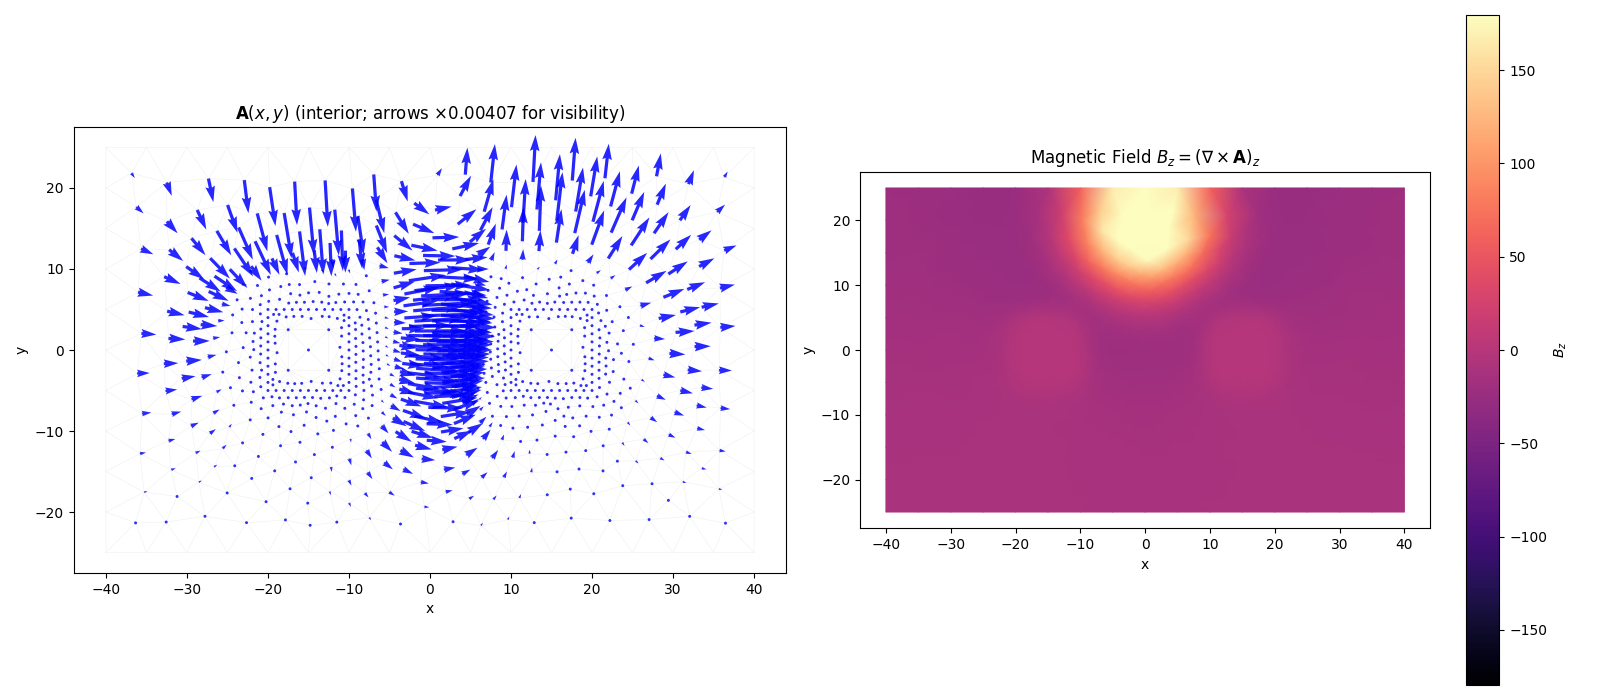

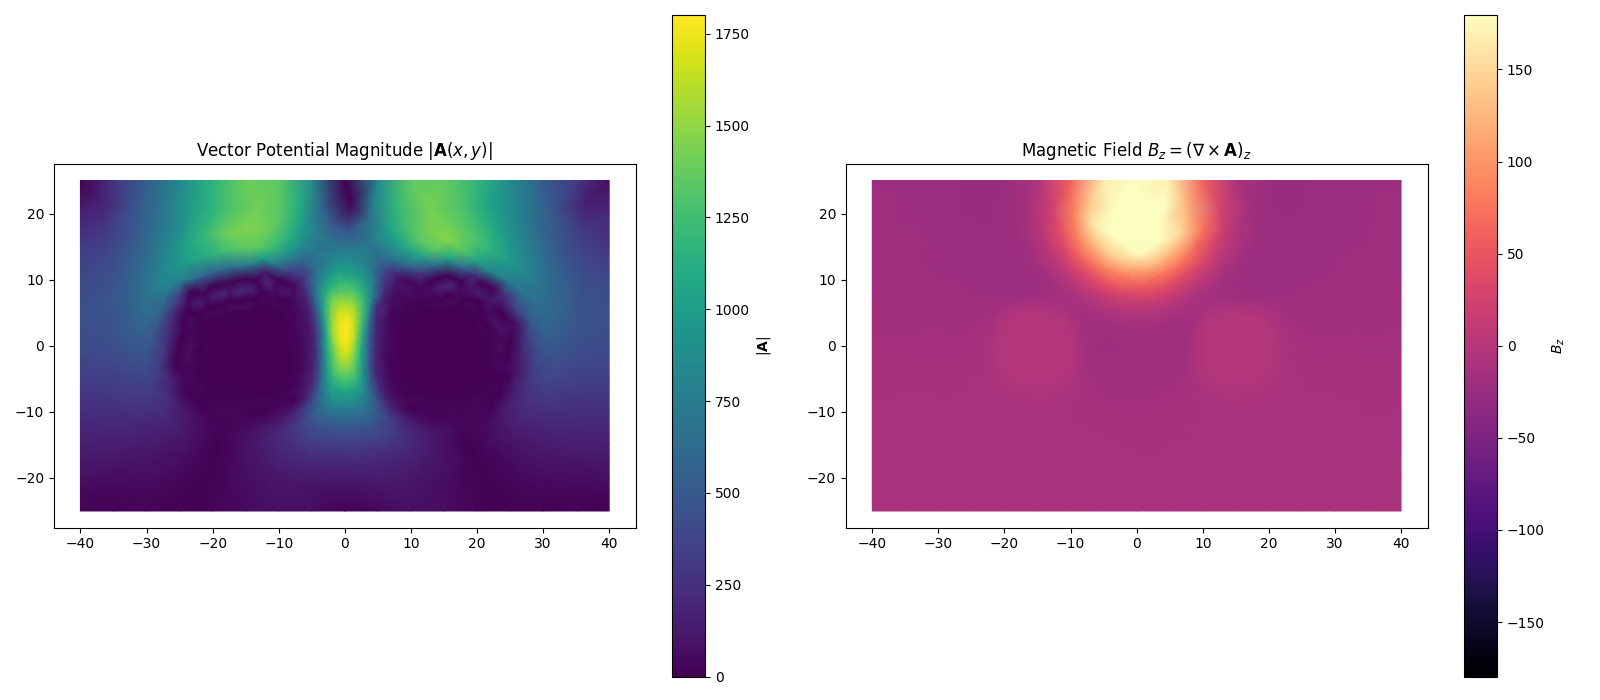

(<Figure size 1600x700 with 4 Axes>,
 array([<Axes: title={'center': 'Vector Potential Magnitude $|\\mathbf{A}(x,y)|$'}>,
        <Axes: title={'center': 'Magnetic Field $B_z = (\\nabla \\times \\mathbf{A})_z$'}>],
       dtype=object))

In [15]:
from scipy.sparse.linalg import spsolve
from skfem import MeshTri, ElementTriN1, ElementTriN2, ElementTriP1, ElementTriP2, Basis, BilinearForm, LinearForm, asm, condense
from skfem.helpers import curl, dot

omega_d = 0
c_bar = 137.036
kappa = 1
area = 800
N_area = 100  # only for b_coeff; do not confuse with pickled particle count

a_coeff = - (omega_d/c_bar)**2
b_coeff = 1/(kappa**2) * area / N_area
print("a_coeff, b_coeff:", a_coeff, b_coeff)

########################################################
# Solver Below
########################################################

nodal_element = femsystem.element  # Get the scikit-fem element used for nodal basis (e.g., ElementTriP1/P2)
nedelic_element = ElementTriN1()
# Same intorder as pickled FEMSystem (often 5 in 2DTwoModesOpt). Otherwise asm(...) rejects
# femsystem.basis.interpolate(psi_exp): quadrature must match basis_edge.
basis_nodal = Basis(mesh, nodal_element, intorder=femsystem.intorder)
basis_edge = Basis(mesh, nedelic_element, intorder=femsystem.intorder)

nodes_x = mesh.p[0]
nodes_y = mesh.p[1]
epsilon = 1e-4
psi_exp = (u_left **2 + u_right**2) * N / 2 + epsilon
# Interpolate psi_exp with femsystem.basis: same FE space as u_* (often P2) and same quadrature
# as basis_edge via intorder above. Using basis_nodal.interpolate(psi_exp) fails (wrong N or wrong quads).

# Strip current on the left (like the working "Initial Test" cell), not a point delta — fills the domain with B.
# On MeshTri2, mesh.p includes midside nodes; P1 nodal DOFs are basis_nodal.N == mesh.nvertices in the *vertex* sense.
# Search closest dof in basis_nodal.doflocs and size b_* with basis_nodal.N so interpolate() agrees.
source_coord = (0.0, 30.0)
source_coord_arr = np.array(source_coord).reshape(2, 1)
dof_xy = basis_nodal.doflocs
closest_node_index = int(np.argmin(np.sum((dof_xy - source_coord_arr) ** 2, axis=0)))
b_nodal_values = np.zeros((2, basis_nodal.N))
b_nodal_values[1, closest_node_index] = 1.0

@BilinearForm
def bilinear_form(u,v,w):
    # / N_area keeps London term O(1) with psi_exp (same balance as your earlier working runs)
    second_term_coeff = a_coeff + b_coeff * w['psi_exp'] / N_area * 100
    return curl(u) * curl(v) + second_term_coeff * dot(u, v)

@LinearForm
def general_source(v, w):
    b_vec = np.array([w['bx'], w['by']])
    return dot(b_vec, v)

@LinearForm
def dipole_source(v, w):
    x = w.x[0]
    y = w.x[1]
    x0, y0 = 0.0, 20.0
    sigma = 10.0
    m = 100000
    M = (m / (np.pi * sigma**2)) * np.exp(-((x - x0)**2 + (y - y0)**2) / sigma**2)
    Jx = -M * 2 * (y - y0) / sigma**2
    Jy =  M * 2 * (x - x0) / sigma**2
    J_vec = np.array([Jx, Jy])
    return dot(J_vec, v)

A_matrix = asm(bilinear_form, basis_edge,
               psi_exp=femsystem.basis.interpolate(np.asarray(psi_exp, dtype=np.float64)))

b_vector = asm(general_source, basis_edge,
               bx=basis_nodal.interpolate(b_nodal_values[0,:]),
               by=basis_nodal.interpolate(b_nodal_values[1,:]))

b_vector = asm(dipole_source, basis_edge)

A_sol = np.zeros(basis_edge.N)
D = basis_edge.get_dofs().all()
A_int, b_int, x_int, I = condense(A_matrix, b_vector, D=D)
A_sol[I] = spsolve(A_int, b_int)

vis = VisualizeVF(mesh, basis_edge, A_sol)
fig, ax = vis.visualize_vf(A_sol, bz_symmetric_percentile=99.0)
vis.visualize_vf_mag(A_sol, bz_symmetric_percentile=99.0)
# vis.visualize_bz_surface(A_sol, bz_symmetric_percentile=99.0)

In [ ]:
from __future__ import annotations

import numpy as np
import jax.numpy as jnp
from scipy.sparse.linalg import spsolve
from skfem import Basis, BilinearForm, ElementTriP1, ElementVector, LinearForm, asm
from skfem.helpers import div, dot
from jax.scipy.sparse.linalg import cg

def _two_by_two(integrand, fs, u_left, u_right):
    """Fill [[LL, LR], [RL, RR]] using femsystem.integrate_two."""
    e_ll = fs.integrate_two(integrand, u_left, u_left)
    e_lr = fs.integrate_two(integrand, u_left, u_right)
    e_rl = fs.integrate_two(integrand, u_right, u_left)
    e_rr = fs.integrate_two(integrand, u_right, u_right)
    return jnp.array([[e_ll, e_lr], [e_rl, e_rr]])

def _project_nedelec_to_vector_p1(femsystem, basis_edge, A_sol: np.ndarray):
    """L² project Nédélec A onto vector P1 (same mesh and quadrature order as modes)."""
    mesh = basis_edge.mesh
    basis_vec_p1 = Basis(
        mesh, ElementVector(ElementTriP1()), intorder=femsystem.intorder
    )

    @BilinearForm
    def mass_vec(u, v, w):
        return dot(u, v)

    @LinearForm
    def rhs_proj(v, w):
        return dot(w["A"], v)

    A_disc = basis_edge.interpolate(np.asarray(A_sol, dtype=np.float64))
    M = asm(mass_vec, basis_vec_p1)
    rhs = asm(rhs_proj, basis_vec_p1, A=A_disc)
    coeffs = spsolve(M, rhs)
    A_p1_disc = basis_vec_p1.interpolate(coeffs)
    val = np.asarray(A_p1_disc.value)
    Ax = jnp.asarray(val[0])
    Ay = jnp.asarray(val[1])
    divA = jnp.asarray(div(A_p1_disc))
    a2 = Ax * Ax + Ay * Ay
    return Ax, Ay, divA, a2

def epsilon_four_terms(
    femsystem,
    basis_edge,
    A_sol,
    phi_i,
    phi_j,
):

    def T_nabla2(u1, g1, u2, g2, x):

        del u1, u2, x
        return -jnp.sum(jnp.conj(g1) * g2, axis=0)

    Ax, Ay, divA, a2 = _project_nedelec_to_vector_p1(femsystem, basis_edge, A_sol)

    def T_divA(u1, g1, u2, g2, x):
        del g1, g2, x
        return 1j*jnp.conj(u1) * divA * u2

    def T_Adot_grad(u1, g1, u2, g2, x):
        del g1, x
        adot = Ax * g2[0] + Ay * g2[1]
        return 1j*jnp.conj(u1) * adot

    def T_A2(u1, g1, u2, g2, x):
        del g1, g2, x
        return jnp.conj(u1) * a2 * u2

    laplacian_term = femsystem.integrate_two(T_nabla2, phi_i, phi_j)
    first_cross_term = femsystem.integrate_two(T_divA, phi_i, phi_j)
    second_cross_term = femsystem.integrate_two(T_Adot_grad, phi_i, phi_j)
    a2_term = femsystem.integrate_two(T_A2, phi_i, phi_j)

    return laplacian_term, first_cross_term, second_cross_term, a2_term

# Without a factor of 4 in front, simply four terms of \int \phi_i^* (i\grad + A)^2 \phi_j dx
epsilon_four_terms(femsystem, basis_edge, A_sol, u_left, u_left)

# Get phi_theta_int, or the green's function times charge background
A_int, P_int = femsystem.get_stiffness_matrix()
theta_at_quad = femsystem._interpolate_values(theta_at_dofs)
weighted_theta = theta_at_quad * femsystem.weights
v_theta = P_int.T @ weighted_theta.ravel()
phi_theta_int, _ = cg(A_int, v_theta)


# Returns a functions of time
def compute_epsilon(femsystem, basis_edge, A_sol, u1,u2,phi_theta_int,omega_d):
    laplacian_term, first_cross_term, second_cross_term, a2_term = epsilon_four_terms(femsystem, basis_edge, A_sol, u_left, u_right)

    # Compute the u_ext integral
    u_quad1 = femsystem._interpolate_values(u1)
    u_quad2 = femsystem._interpolate_values(u2)
    weighted_u2 = (u_quad1*u_quad2) * femsystem.weights
    v_u2 = P_int.T @ weighted_u2.ravel()
    potential = -2 * (v_u2 @ phi_theta_int)

    def epsilon_func(t):
        return 4*(laplacian_term + first_cross_term*jnp.sin(omega_d*t) + second_cross_term*jnp.sin(omega_d*t) + a2_term*jnp.sin(2*omega_d*t)) + potential

    return epsilon_func

def compute_U(u1,u2,u3,u4,area,N):
    left_func = u1 * u2
    right_func = u3 * u4
    return area / N * femsystem.double_integral_cg(lambda u1,a,u2,c,d: u1, lambda u1,b,u2,c,d: u2, A_int, P_int, left_func, right_func)

compute_epsilon(femsystem, basis_edge, A_sol, u_left, u_right)

(Array(-0.06611797, dtype=float32),
 Array(0.-0.02990995j, dtype=complex64),
 Array(0.+0.01495496j, dtype=complex64),
 Array(235.15776, dtype=float32))

In [ ]:
import jax.numpy as jnp

def charge_imbalance_eigenvalues(n, N):
    """
    Returns array of length n, giving the charge imbalance (left minus right) eigenvalues.
    """
    # n: number of states kept (should be central band)
    # N: total particle number
    # The mid n charge imbalance eigenstates always centered around zero, integer or half.
    if n % 2 == 0:
        # n even -> N odd (e.g. for even n take odd N)
        center = 0.5  # half integers
        m_values = jnp.arange(-n//2, n//2) + center  # e.g. [-3.5, -2.5, ..., +3.5] if n=8
    else:
        # n odd -> N even (e.g. for odd n take even N)
        center = 0  # integers
        m_values = jnp.arange(-(n//2), n//2 + 1)  # e.g. [-4, -3, ..., +4] if n=9
    # Total left number operator eigenvalues. 
    # Left particle number: (N + m) / 2
    # Right particle number: (N - m) / 2
    n_left_values = (N + m_values) / 2
    n_right_values = (N - m_values) / 2
    return m_values, n_left_values, n_right_values

def total_left_operator(n, N):
    """
    Returns the total left operator matrix (n x n diagonal) for left particle number in the middle n states.
    """
    m_values, n_left_values, n_right_values = charge_imbalance_eigenvalues(n, N)
    return jnp.diag(n_left_values)

def total_right_operator(n, N):
    """
    Returns the total right operator matrix (n x n diagonal) for right particle number in the middle n states.
    """
    m_values, n_left_values, n_right_values = charge_imbalance_eigenvalues(n, N)
    return jnp.diag(n_right_values)

def left_raising_operator(n, N):
    """
    Returns (n x n) raising operator matrix for adding a particle to the left mode.
    """
    m_values, n_left_values, n_right_values = charge_imbalance_eigenvalues(n, N)
    # |m> -> |m+1>, but only if |m+1> exists in range
    mat = jnp.zeros((n, n))
    for i in range(n-1):
        # m at i, m+1 at i+1; raising from |m> to |m+1>
        mat = mat.at[i+1, i].set(jnp.sqrt(n_left_values[i] + 1))
    return mat

def left_lowering_operator(n, N):
    """
    Returns (n x n) lowering operator matrix for removing a particle from the left mode.
    """
    m_values, n_left_values, n_right_values = charge_imbalance_eigenvalues(n, N)
    # |m> -> |m-1>, only if |m-1> exists in range
    mat = jnp.zeros((n, n))
    for i in range(1, n):
        # lowering from |m> at i to |m-1> at i-1
        mat = mat.at[i-1, i].set(jnp.sqrt(n_left_values[i]))
    return mat

def right_raising_operator(n, N):
    """
    Returns (n x n) raising operator matrix for adding a particle to the right mode.
    """
    m_values, n_left_values, n_right_values = charge_imbalance_eigenvalues(n, N)
    # |m> -> |m-1>, right raising lowers m
    mat = jnp.zeros((n, n))
    for i in range(0, n-1):
        # m at i, m-1 at i+1
        mat = mat.at[i+1, i].set(jnp.sqrt(n_right_values[i] + 1))
    return mat

def right_lowering_operator(n, N):
    """
    Returns (n x n) lowering operator matrix for removing a particle from the right mode.
    """
    m_values, n_left_values, n_right_values = charge_imbalance_eigenvalues(n, N)
    # |m> -> |m+1>, right lowering raises m
    mat = jnp.zeros((n, n))
    for i in range(1, n):
        # m at i, m+1 at i-1
        mat = mat.at[i-1, i].set(jnp.sqrt(n_right_values[i]))
    return mat


In [ ]:
{'nabla_dot_nabla': Array([[-0.06611797,  0.00455319],
        [ 0.00455319, -0.06633193]], dtype=float32),
 'nabla_dot_A': Array([[ 2.9909950e-09,  1.7592566e-11],
        [ 1.7592622e-11, -3.5402588e-09]], dtype=float32),
 'A_dot_nabla': Array([[-2.9909959e-09, -4.4614570e-09],
        [ 4.4262727e-09,  3.5402619e-09]], dtype=float32),
 'A_dot_A': Array([[2.3515777e-12, 1.2073485e-12],
        [1.2073485e-12, 2.3462859e-12]], dtype=float32)}

# Widget Visualization

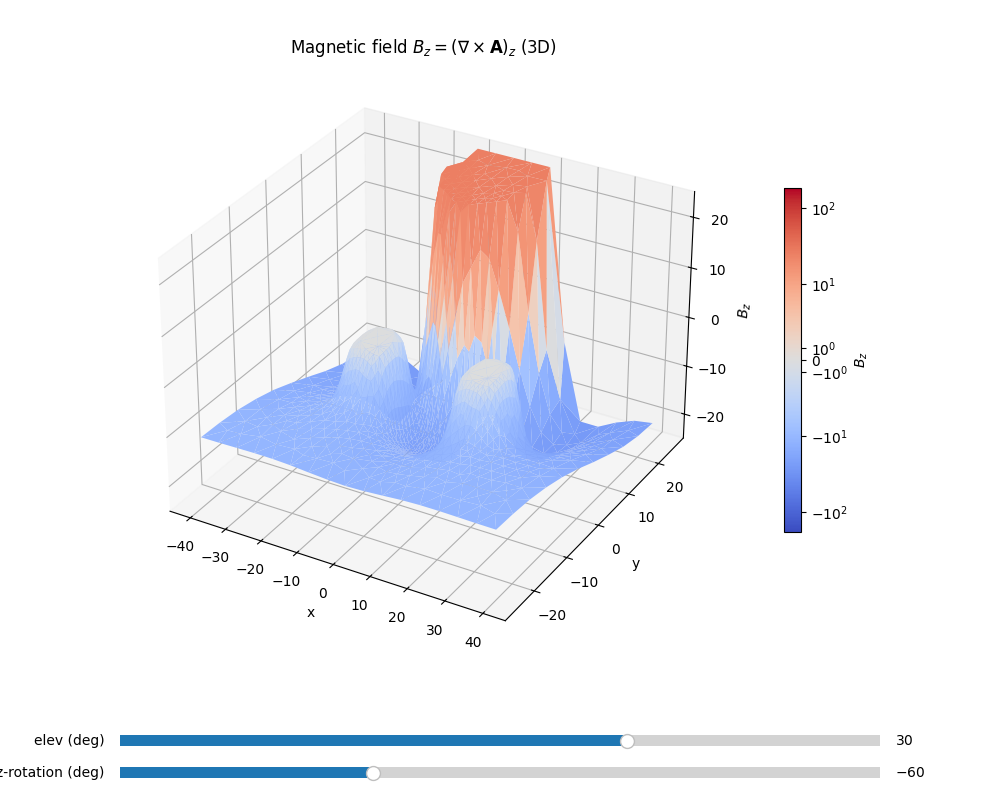

(<Figure size 1000x800 with 4 Axes>,
 <Axes3D: title={'center': 'Magnetic field $B_z = (\\nabla \\times \\mathbf{A})_z$ (3D)'}, xlabel='x', ylabel='y', zlabel='$B_z$'>)

In [17]:
%matplotlib widget
vis.visualize_bz_surface(A_sol, bz_symmetric_percentile=99.0)

In [ ]:
# Now compute 

# Initial Test Below

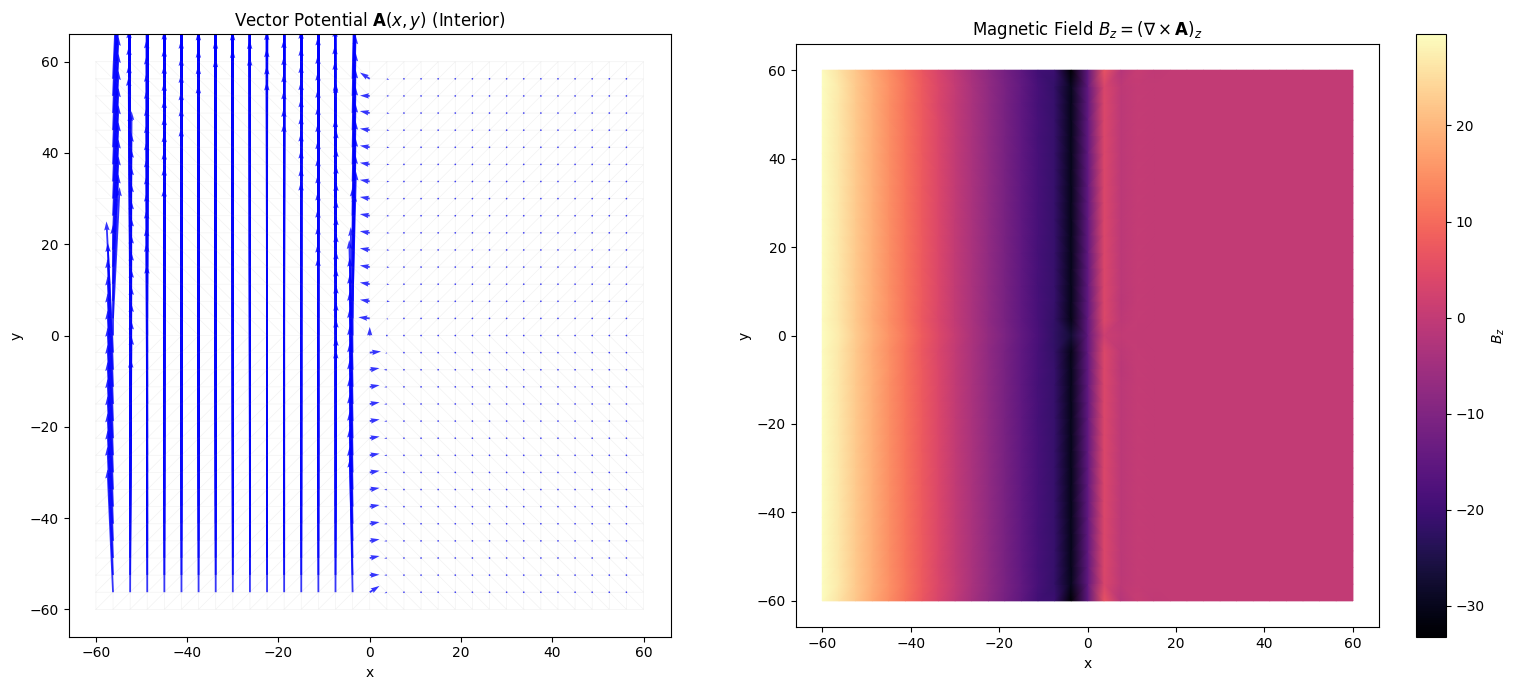

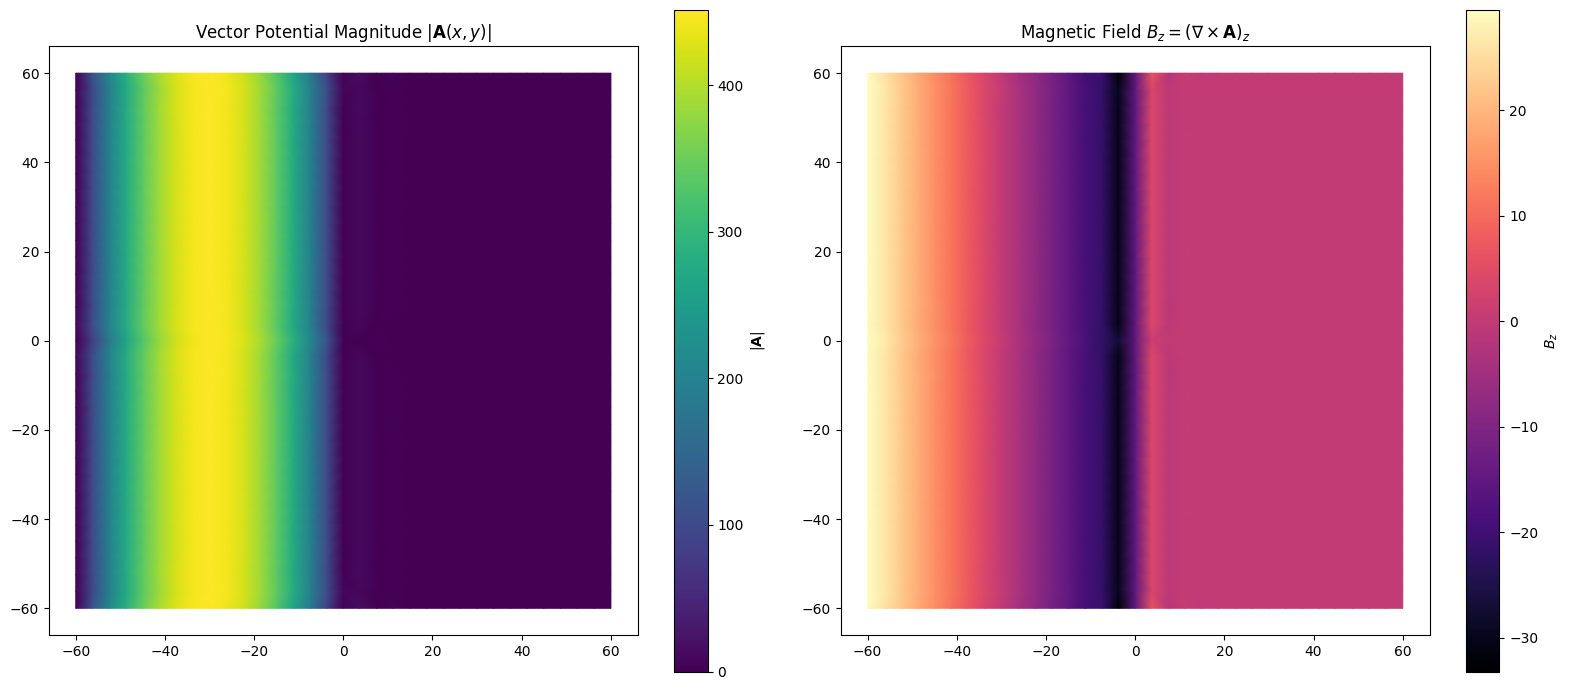

(<Figure size 1600x700 with 4 Axes>,
 array([<Axes: title={'center': 'Vector Potential Magnitude $|\\mathbf{A}(x,y)|$'}>,
        <Axes: title={'center': 'Magnetic Field $B_z = (\\nabla \\times \\mathbf{A})_z$'}>],
       dtype=object))

In [ ]:
from scipy.sparse.linalg import spsolve
from skfem import MeshTri, ElementTriN1, ElementTriP1, Basis, BilinearForm, LinearForm, asm, condense
from skfem.helpers import curl, dot

nodal_element = ElementTriP1()
nedelic_element = ElementTriN1()
basis_nodal = Basis(mesh, nodal_element, intorder=femsystem.intorder)
basis_edge = Basis(mesh, nedelic_element, intorder=femsystem.intorder)

# Simply add in filler a and b (length basis_nodal.N — P1 vertices, not len(mesh.p) on MeshTri2)
nodes_x = basis_nodal.doflocs[0]
epsilon = 1e-8
a_nodal_values = np.where(nodes_x > 0.5, 100.0, epsilon)

b_nodal_values = np.zeros((2, basis_nodal.N))
b_nodal_values[1, :] = 1.0 * (nodes_x < 0.2)  # strip source

@BilinearForm
def bilinear_form(u,v,w):
    # w['a_field'] is a scalar interpolated to the quadratures
    return curl(u) * curl(v) + w['a_field'] * dot(u, v)

@LinearForm
def general_source(v, w):
    # w['b_field'] picks off column of two elements, both scalars interpolated to the quadatures
    b_vec = np.array([w['bx'], w['by']])
    
    # dot() takes the inner product of the source vector and the test function vector 'v'
    return dot(b_vec, v)

A_matrix = asm(bilinear_form, basis_edge, 
               a_field=basis_nodal.interpolate(a_nodal_values))

b_vector = asm(general_source, basis_edge, 
               bx=basis_nodal.interpolate(b_nodal_values[0,:]),
               by=basis_nodal.interpolate(b_nodal_values[1,:]))

# SOLVE
# Enforce tangential A = 0 on boundaries
A_sol = np.zeros(basis_edge.N) # simply a vector of zeros, length of DOFs (nedelic elements)
D = basis_edge.get_dofs().all() # get the boundary indices
A_int, b_int, x_int, I = condense(A_matrix, b_vector, D=D) # condense matrices, I is indices of the interior DOFs
A_sol[I] = spsolve(A_int, b_int) # solve and put into interior only


# VISUALIZE
vis = VisualizeVF(mesh,basis_edge,A_sol)
fig, ax = vis.visualize_vf(A_sol)
vis.visualize_vf_mag(A_sol)

# Calculations for charge density

### Diamagnetic matrix $\epsilon_{ij}^{A^2}$ (minimal coupling)

From $(\cdots - q{A})^2$, the **pure $|A|^2$** piece is $(q^2/2m)|A|^2$. With ${A}$ from the Nédélec solve and modes on `femsystem`:

$$\epsilon_{ij}^{A^2} = \frac{q^2}{2m} \int \phi_i^*\, |A|^2\, \phi_j \,\mathrm{d}x$$

The code below returns a $2\times 2$ matrix $[\langle L|\cdot|L\rangle, \langle L|\cdot|R\rangle; \langle R|\cdot|L\rangle, \langle R|\cdot|R\rangle]$.

In [ ]:
# (q^2/2m) ∫ φ_i* |A|^2 φ_j dx  for i,j ∈ {left, right}; A = Nédélec A_sol, modes = femsystem scalar DOFs
from epsilon_A2_coupling import epsilon_diamagnetic_left_right_2x2

eps_A2 = epsilon_diamagnetic_left_right_2x2(
    femsystem,
    basis_edge,
    A_sol,
    u_left,
    u_right,
    q=1.0,
    m=1.0,
)
print("ε^A2 [[LL, LR], [RL, RR]]:")
print(np.asarray(eps_A2))

In [ ]:
# ∫ φ_i* [expanded (∇ − A)²] φ_j — four 2×2 blocks; A = Nédélec A_sol (see minimal_coupling_four_terms.py)
from minimal_coupling_four_terms import grad_minus_A_squared_four_terms_2x2

terms = grad_minus_A_squared_four_terms_2x2(femsystem, basis_edge, A_sol, u_left, u_right)
for name, mat in terms.items():
    print(name, ":")
    print(np.asarray(mat))

In [5]:
# Returns array where at index i, it is the true charge imbalance of the coefficient at the ith index
# Remember, length of the coeffs array is n, so will represent a maximum charge imbalance of n-1.
# convention for charge imbalance is defined by Right - Left i think??
def true_charge_imbalances(n):
    if n % 2 == 1:  # odd
        center = n // 2
        return [2 * (center - i) for i in range(n)]
    else:  # even
        center_right = n // 2
        return [2 * (center_right - i) - 1 for i in range(n)]

charge_imbalance_labels = true_charge_imbalances(len(coeffs))

# For finite N, what I want labels that tell me how much is on left, how much is on right
# N is total number of particles, n is total domain of 
half_charge_imbalance = (n-1)/2 - jnp.arange(n) # from (n-1)/2 to -(n-1)/2
num_left = N/2 + half_charge_imbalance
num_right = N/2 - half_charge_imbalance

# Normalize coeffs:
coeffs = coeffs / jnp.sqrt(jnp.sum(jnp.abs(coeffs)**2))
print(jnp.sum(jnp.abs(coeffs)**2))

exp_val_left = jnp.sum(num_left * coeffs**2)
exp_val_right = jnp.sum(num_right * coeffs**2)

# For a symmetric set of coefficients, this should be exactly N/2 for both
print(exp_val_left,exp_val_right,N/2)

0.99999994
35.0 35.0 35.0
